In [1]:
import pandas as pd 
import datetime as dt 
import matplotlib.pyplot as plt 
import seaborn as sns 

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Valores faltantes
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [3]:
# Pasaremos los nombres a minúscula y también quitaremos espacios extra, como al principio y final de una palabra. 
df.columns = [col.lower() for col in df.columns]
print(df.columns)

# Eliminamos nulos en customerid
df = df.dropna(subset=['customerid'])

# Hacemos una limpieza selectiva en las columnas que son texto
columnas_texto = ['description', 'country']

for col in columnas_texto:
    df[col] = df[col].astype(str).str.lower().str.strip()
print('Limpieza selectiva completada')

# Pasamos a números enteros la columna customerid  
df['customerid'] = df['customerid'].astype(int)

# Quitamos ventas e negativo y cancelaciones. 
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)]
df = df[~df['invoiceno'].astype(str).str.startswith('c')]

# Creamos la columna de valor total
df['totalsum'] = df['quantity'] * df['unitprice']

print(df.info())
df.head()


Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')
Limpieza selectiva completada
<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    397884 non-null  object        
 1   stockcode    397884 non-null  object        
 2   description  397884 non-null  str           
 3   quantity     397884 non-null  int64         
 4   invoicedate  397884 non-null  datetime64[us]
 5   unitprice    397884 non-null  float64       
 6   customerid   397884 non-null  int64         
 7   country      397884 non-null  str           
 8   totalsum     397884 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), object(2), str(2)
memory usage: 30.4+ MB
None


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalsum
0,536365,85123A,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,united kingdom,15.30
1,536365,71053,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,united kingdom,20.34
2,536365,84406B,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,united kingdom,22.00
3,536365,84029G,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,united kingdom,20.34
4,536365,84029E,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,united kingdom,20.34


In [4]:
# como el df es un poco viejo vamos a calcular día después de la ultima factura 
snapshop_day = df['invoicedate'].max() + dt.timedelta(days=1)
print(f'Nuestra fecha de referencia es: {snapshop_day}')


Nuestra fecha de referencia es: 2011-12-10 12:50:00


In [5]:
#Agrupamos y calculamos nuestra Recencia, Frecuencia y Monetario (RFM)
rfm = df.groupby('customerid').agg({
    'invoicedate' : lambda x: (snapshop_day - x.max()).days,
    'invoiceno' : 'count',
    'totalsum' : 'sum'
})

#Renombramos 
rfm.rename(columns= {
    'invoicedate' : 'recency',
    'invoiceno' : 'frecuency',
    'totalsum' : 'monetaryvalue'
}, inplace=True)

rfm.head()


,recency,frecuency,monetaryvalue
customerid,,,
12346,326,1,77183.60
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


In [6]:
rfm.describe()

,recency,frecuency,monetaryvalue
count,4338.000000,4338.000000,4338.000000
mean,92.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,307.415000
50%,51.000000,41.000000,674.485000
75%,142.000000,100.000000,1661.740000
max,374.000000,7847.000000,280206.020000


In [7]:
#creamos el puntaje de recencia 
rfm['recency_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])

#creamos el puntaje de frecuencia 
rfm['frecuency_score'] = pd.qcut(rfm['frecuency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

#creamos el puntaje monetario 
rfm['monetary_score'] = pd.qcut(rfm['monetaryvalue'], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,recency,frecuency,monetaryvalue,recency_score,frecuency_score,monetary_score
customerid,,,,,,
12346,326,1,77183.60,1,1,5
12347,2,182,4310.00,5,5,5
12348,75,31,1797.24,2,3,4
12349,19,73,1757.55,4,4,4
12350,310,17,334.40,1,2,2


Análisis de la segmentación:
Cliente 12347: Es un 5-5-5. Compró hace poco (5), compra muchísimo (5) y gasta un montón (5). Este es tu "Campeón".

Cliente 12346: Es un 1-1-5. Fue un cliente de alto valor monetario (5), pero su recencia y frecuencia son mínimas (1). Seguramente fue una compra única y grande hace mucho tiempo.

Cliente 12350: Es un 1-2-2. Está fallando en todo; es un cliente que se está yendo o ya se fue.

In [8]:
# combinamos recencia y frecuencia en un solo string para segmentarlos 
rfm['rfm_score'] = rfm['recency_score'].astype(str) + rfm['frecuency_score'].astype(str)

rfm.head()

,recency,frecuency,monetaryvalue,recency_score,frecuency_score,monetary_score,rfm_score
customerid,,,,,,,
12346,326,1,77183.60,1,1,5,11
12347,2,182,4310.00,5,5,5,55
12348,75,31,1797.24,2,3,4,23
12349,19,73,1757.55,4,4,4,44
12350,310,17,334.40,1,2,2,12


In [9]:
#definimos el mapa de traducción 
seg_map = {
    r'[1-2][1-2]' : 'hibernating',
    r'[1-2][3-4]' : 'at_Risk',
    r'[1-2]5' : 'cant_loose',
    r'3[1-2]' : 'about_to_sleep',
    r'33' : 'need_attention',
    r'[3-4][4-5]' : 'loyal_customers',
    r'41' : 'promising',
    r'51' : 'new_customers',
    r'[4-5][2-3]' : 'potential_loyallist',
    r'5[4-5]' : 'champions'
}

#aplicamos el mapa a la columna rfm_score para crear la columna 'segment'
rfm['segment'] = rfm['rfm_score'].replace(seg_map, regex=True)

rfm.head()

,recency,frecuency,monetaryvalue,recency_score,frecuency_score,monetary_score,rfm_score,segment
customerid,,,,,,,,
12346,326,1,77183.60,1,1,5,11,hibernating
12347,2,182,4310.00,5,5,5,55,champions
12348,75,31,1797.24,2,3,4,23,at_Risk
12349,19,73,1757.55,4,4,4,44,loyal_customers
12350,310,17,334.40,1,2,2,12,hibernating


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10152\1962485958.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= segment_counts.index, y = segment_counts.values, palette='viridis')


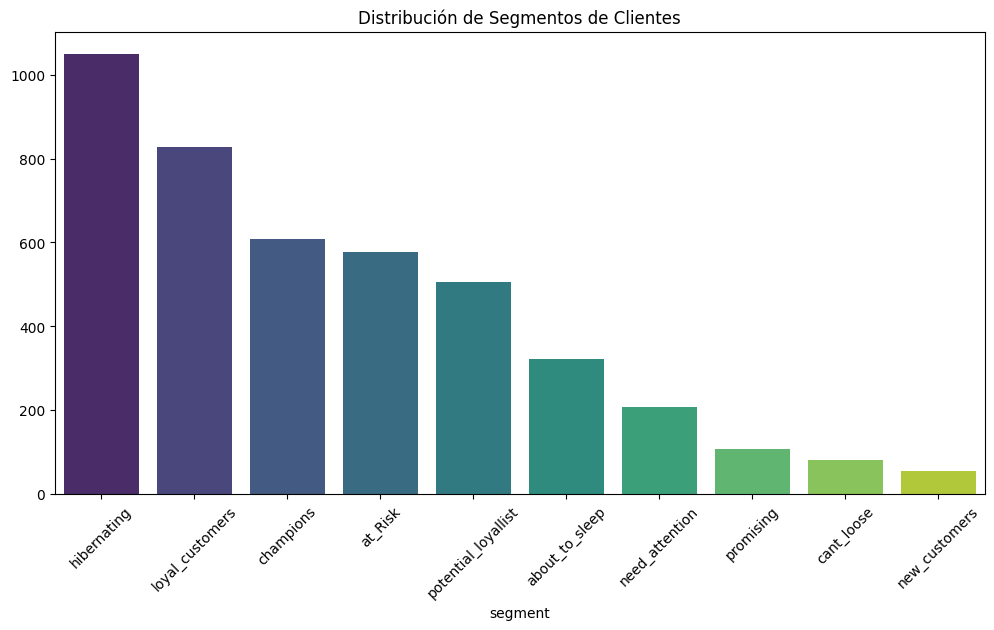

In [10]:
# contamos cuántos clientas hay en cada segmento
segment_counts = rfm['segment'].value_counts()

#creamos una gráfica de barras para verlo claramente
plt.figure(figsize=(12, 6))
sns.barplot(x= segment_counts.index, y = segment_counts.values, palette='viridis')
plt.title('Distribución de Segmentos de Clientes')
plt.xticks(rotation=45)
plt.show()

En la gráfica podemos ver que la barra más alta es hibernating, esto significa que muchísimos clientes que compraron alguna vez y han sido olvidados, vemos un núcleo fuerte, hay una buena cantidad en columnas como loyal_cusomers y champions pero la barra de new_customers es de las más bajas, esto nos dice que a la tienda le está costando atraer gente nueva. 

El análisis RFM reveló que el 25% de la base de clientes está en estado de hibernación, lo que representa una oportunidad de reactivación masiva. Por otro lado, nuestros 'Champions' representan el motor del negocio, manteniendo una frecuencia de compra constante. Se recomienda priorizar campañas de retención para el segmento 'At Risk' para evitar la fuga de clientes de alto valor.

Estrategias sugueridas: 
-	Para champions (55) : recompensar su lealtad, no necesitan descuentos para comprar porque ya lo hacen, necesitan sentirse especiales.
-	¿Cómo?: acceso anticipado a nuevas colecciones o algún programa de puntos redimibles exclusivos

-	Para los loyal_customers (45): venta cruzada

-	¿Cómo?: recomendar productos complementarios a lo que siempre comprar para aumentar su gasto promedio.

-	Para los At Risk (1-2 en recencia): reactivación inmediata. Estamos por perderlos.

-	¿Cómo?: utilizar medios de comunicación como correos o mensajes directos con cupones con tiempo limitado para reducir el tiempo de activación.

-	Para los hibernating: limpieza o re interés masivo.

-	¿Cómo?: campaña de marketing para ver su interés, si no responden a la campaña podríamos considerar en eliminarlos de las campañas pagas para ahorrar costos. 
